# Task 2: Predictive Modeling

**Project**: GenAI Powered Data Analytics - Tata iQ  
**Client**: Geldium Finance  
**Objective**: Build and evaluate a predictive model for customer delinquency.

---

## 1. Introduction

This notebook covers the development of a Decision Tree model to predict delinquency risk using insights from Task 1.

## 2. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

print("✅ All libraries imported successfully for Task 2")

✅ All libraries imported successfully for Task 2


## Load Cleaned Data

In [8]:
df = pd.read_excel("/Users\HP/Projects/Gen AI Powered Data Analytics/Cleaned_Delinquency_Dataset_with_New_Target.xlsx")

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_23124\4187339961.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_excel("/Users\HP/Projects/Gen AI Powered Data Analytics/Cleaned_Delinquency_Dataset_with_New_Target.xlsx")


## 3. Feature Selection & Target

In [9]:
features = ['Missed_Payments', 'Credit_Utilization', 'Credit_Score', 'Debt_to_Income_Ratio', 'Income', 'Age', 'Account_Tenure',]

X = df[features]
y = df['Delinquent_Account_New'] 

print(f"Features used: {features}")
print(f"Shape of X: {X.shape}")

Features used: ['Missed_Payments', 'Credit_Utilization', 'Credit_Score', 'Debt_to_Income_Ratio', 'Income', 'Age', 'Account_Tenure']
Shape of X: (500, 7)


## 4. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 400
Testing samples: 100


## 5. Model Training

In [11]:
model = DecisionTreeClassifier(max_depth = 5, random_state = 42)
model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully")

✅ Decision Tree model trained successfully


## 6. Model Evaluation

Classification Report:
                precision    recall  f1-score   support

Non-Delinquent       1.00      1.00      1.00        49
    Delinquent       1.00      1.00      1.00        51

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100


AUC-ROC Score: 1.0000


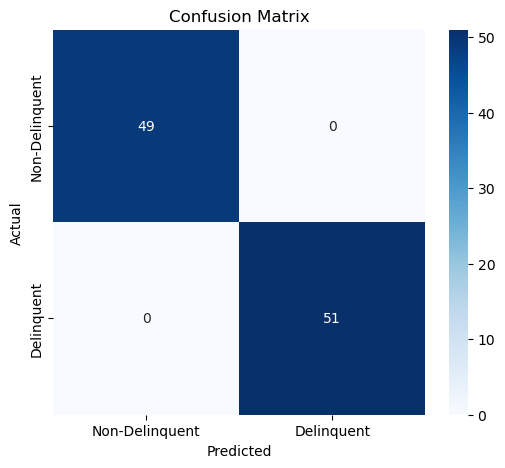

In [12]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Delinquent', 'Delinquent']))

print(f"\nAUC-ROC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Delinquent', 'Delinquent'],
            yticklabels=['Non-Delinquent', 'Delinquent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. Feature Importance

Feature Importance:


,Feature,Importance
0,Missed_Payments,0.732089
1,Credit_Utilization,0.267911
2,Credit_Score,0.000000
3,Debt_to_Income_Ratio,0.000000
4,Income,0.000000
5,Age,0.000000
6,Account_Tenure,0.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_23124\1697174477.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='Blues_r')


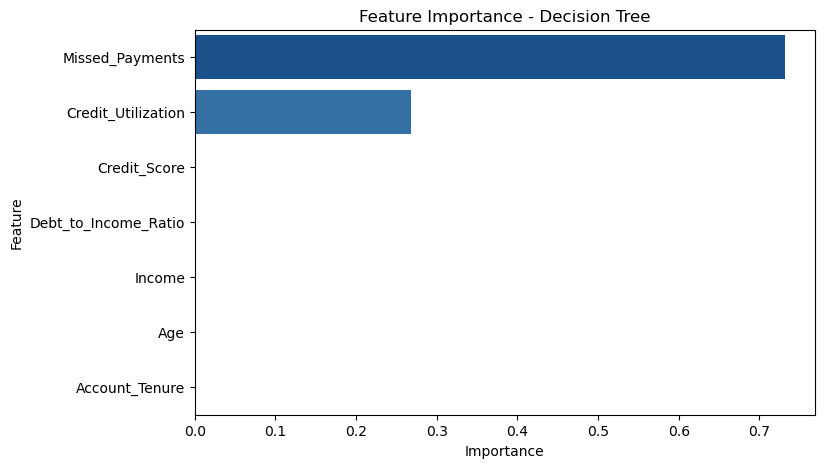

In [13]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
display(importance)

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance - Decision Tree')
plt.show()

In [14]:
import joblib
joblib.dump(model, 'delinquency_decision_tree_model.pkl')


df.to_excel('Final_Cleaned_Dataset_for_Task2.xlsx', index=False)
print("✅ Model and final dataset saved")

✅ Model and final dataset saved


## 8. Improved Target Creation (with some noise)

In [15]:
np.random.seed(42)

df['Delinquent_Account_New'] = 0

high_risk = (df['Missed_Payments'] >= 4) | (df['Credit_Utilization'] > 0.68)

# Added some randomness so the model has to learn
random_noise = np.random.rand(len(df)) < 0.15   # 15% noise
df.loc[high_risk & ~random_noise, 'Delinquent_Account_New'] = 1
df.loc[~high_risk & random_noise, 'Delinquent_Account_New'] = 1

print("New Target Distribution:")
print(df['Delinquent_Account_New'].value_counts(normalize=True))

New Target Distribution:
Delinquent_Account_New
1    0.52
0    0.48
Name: proportion, dtype: float64


## 9. Retrain Model with Better Control

In [16]:
features = ['Missed_Payments', 'Credit_Utilization', 'Credit_Score', 
            'Debt_to_Income_Ratio', 'Account_Tenure', 'Income', 'Age']

X = df[features]
y = df['Delinquent_Account_New']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Decision Tree with controlled depth
model = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Delinquent', 'Delinquent']))

print(f"\nAUC-ROC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Classification Report:
                precision    recall  f1-score   support

Non-Delinquent       0.84      0.79      0.82        48
    Delinquent       0.82      0.87      0.84        52

      accuracy                           0.83       100
     macro avg       0.83      0.83      0.83       100
  weighted avg       0.83      0.83      0.83       100


AUC-ROC Score: 0.8680


## 10. Feature Importance & Visualization

Feature Importance:


,Feature,Importance
0,Missed_Payments,0.621708
1,Credit_Utilization,0.249219
5,Income,0.036380
3,Debt_to_Income_Ratio,0.035044
2,Credit_Score,0.033415
4,Account_Tenure,0.024234
6,Age,0.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_23124\3913322654.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


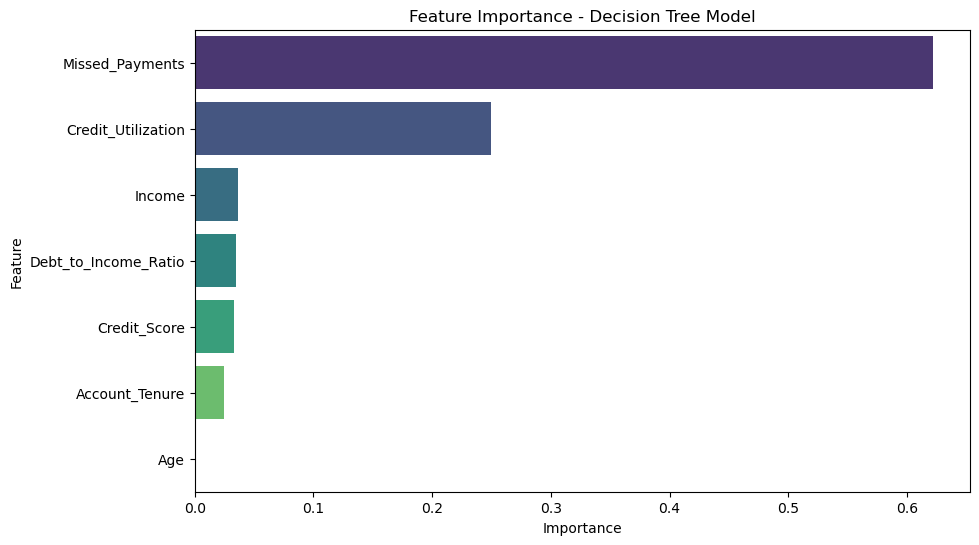

In [17]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
display(importance)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Decision Tree Model')
plt.savefig("Feature Importance - Decision Tree Model.png", dpi=300, bbox_inches='tight')
plt.show()

## End of Task 2